## Dataset Analysis
Perform analysis on distribution of traffic, types of attacks present, and infer the possible variables that may be the factor for attack patterns.

In [ ]:
!pip install -r requirements.txt

In [18]:
import pandas as pd

train_dataset_df = pd.read_csv("./dataset/KDDTrain+.txt")
train_dataset_df.columns = (["duration"
    ,"protocol"
    ,"service"
    ,"flag"
    ,"src_bytes"
    ,"dst_bytes"
    ,"land"
    ,"wrong_fragment"
    ,"urgent"
    ,"hot"
    ,"num_failed_logins"
    ,"logged_in"
    ,"num_compromised"
    ,"root_shell"
    ,"su_attempted"
    ,"num_root"
    ,"num_file_creations"
    ,"num_shells"
    ,"num_access_files"
    ,"num_outbound_cmds"
    ,"is_host_login"
    ,"is_guest_login"
    ,"count"
    ,"srv_count"
    ,"serror_rate"
    ,"srv_serror_rate"
    ,"rerror_rate"
    ,"srv_rerror_rate"
    ,"same_srv_rate"
    ,"diff_srv_rate"
    ,"srv_diff_host_rate"
    ,"dst_host_count"
    ,"dst_host_srv_count"
    ,"dst_host_same_srv_rate"
    ,"dst_host_diff_srv_rate"
    ,"dst_host_same_src_port_rate"
    ,"dst_host_srv_diff_host_rate"
    ,"dst_host_serror_rate"
    ,"dst_host_srv_serror_rate"
    ,"dst_host_rerror_rate"
    ,"dst_host_srv_rerror_rate"
    ,"traffic_type"
    ,"level"
])

In [19]:
train_dataset_df.head()

,duration,protocol,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,traffic_type,level
0,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune,21


In [20]:
train_dataset_df.describe().T

,count,mean,std,min,25%,50%,75%,max
duration,125972.0,287.146929,2.604526e+03,0.0,0.00,0.00,0.00,4.290800e+04
src_bytes,125972.0,45567.100824,5.870354e+06,0.0,0.00,44.00,276.00,1.379964e+09
dst_bytes,125972.0,19779.271433,4.021285e+06,0.0,0.00,0.00,516.00,1.309937e+09
land,125972.0,0.000198,1.408613e-02,0.0,0.00,0.00,0.00,1.000000e+00
wrong_fragment,125972.0,0.022688,2.535310e-01,0.0,0.00,0.00,0.00,3.000000e+00
urgent,125972.0,0.000111,1.436608e-02,0.0,0.00,0.00,0.00,3.000000e+00
hot,125972.0,0.204411,2.149977e+00,0.0,0.00,0.00,0.00,7.700000e+01
num_failed_logins,125972.0,0.001222,4.523932e-02,0.0,0.00,0.00,0.00,5.000000e+00
logged_in,125972.0,0.395739,4.890107e-01,0.0,0.00,0.00,1.00,1.000000e+00
num_compromised,125972.0,0.279253,2.394214e+01,0.0,0.00,0.00,0.00,7.479000e+03


In [21]:
train_dataset_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 125972 entries, 0 to 125971
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125972 non-null  int64  
 1   protocol                     125972 non-null  str    
 2   service                      125972 non-null  str    
 3   flag                         125972 non-null  str    
 4   src_bytes                    125972 non-null  int64  
 5   dst_bytes                    125972 non-null  int64  
 6   land                         125972 non-null  int64  
 7   wrong_fragment               125972 non-null  int64  
 8   urgent                       125972 non-null  int64  
 9   hot                          125972 non-null  int64  
 10  num_failed_logins            125972 non-null  int64  
 11  logged_in                    125972 non-null  int64  
 12  num_compromised              125972 non-null  int64  
 13  root_shell

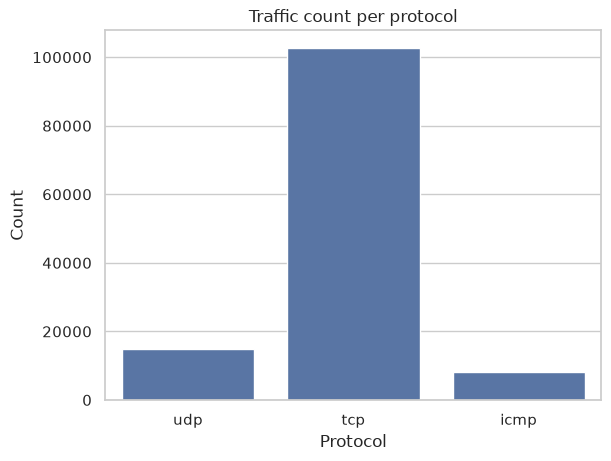

In [22]:
import seaborn as sn
import matplotlib.pyplot as plt

# show all the protocols available from the dataset
protocols = train_dataset_df["protocol"].unique()
plot_data = {
    "Protocol": list(protocols),
    "Count": []
}

for protocol in protocols:
    protocol_count = (train_dataset_df["protocol"] == protocol).sum()
    plot_data["Count"].append(protocol_count)

# load a dataframe for the plot data
df = pd.DataFrame(plot_data)

sn.set_theme(style="whitegrid")
sn.barplot(df, x="Protocol", y="Count")

plt.title("Traffic count per protocol")
plt.show()

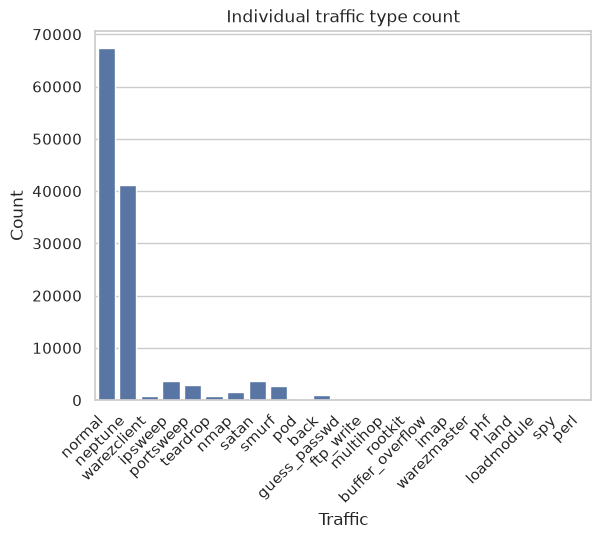

Traffic Count:
normal ==> 67342
neptune ==> 41214
warezclient ==> 890
ipsweep ==> 3599
portsweep ==> 2931
teardrop ==> 892
nmap ==> 1493
satan ==> 3633
smurf ==> 2646
pod ==> 201
back ==> 956
guess_passwd ==> 53
ftp_write ==> 8
multihop ==> 7
rootkit ==> 10
buffer_overflow ==> 30
imap ==> 11
warezmaster ==> 20
phf ==> 4
land ==> 18
loadmodule ==> 9
spy ==> 2
perl ==> 3


In [35]:
# show all the protocols available from the dataset
traffic_types = train_dataset_df["traffic_type"].unique()
plot_data = {
    "Traffic": list(traffic_types),
    "Count": []
}

for traffic_type in traffic_types:
    total_count = (train_dataset_df["traffic_type"] == traffic_type).sum()
    plot_data["Count"].append(total_count)

# load a dataframe for the plot data
df = pd.DataFrame(plot_data)

sn.set_theme(style="whitegrid")
sn.barplot(df, x="Traffic", y="Count")

plt.title("Individual traffic type count")
plt.xticks(rotation=45, ha='right') 
plt.show()

# show in terminal what are the specific counts for each data
print("Traffic Count:")
print("===========================")
for i, traffic_type in enumerate(plot_data["Traffic"]):
    print(traffic_type, "==>", plot_data["Count"][i])
